In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,precision_recall_curve,average_precision_score, auc, RocCurveDisplay
from sklearn.model_selection import learning_curve
from sklearn.utils import resample

In [2]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def count_aminoacids(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    return counts

In [3]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\train_data.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")

In [4]:
print(train_df.head())
print("\n", val_df.head())

   Cluster_name                                 CDR_sequence      Nanobody_id  \
0             1  GSISAYSIISDGGITHQPPGNNAPVRPQVTGPVTGGGVPALPY  Nb_f653aa71b7bc   
1             3   GNISYKSYISRGANTDPGGFYGAVRAVDSNLDTTLYRYTLDY  Nb_dac287f2b235   
2             4   CTIYAYAYINTGSNTLLICVFFLVSAVYYWADLNLLVSVFVY  Nb_bb9361f5dafc   
3            14     GTISYGRYIAPGASTIRVIFVDSAEYYSADGLLNDFRFVY  Nb_dc3832f62569   
4            26      GNISYGKYITDGTITAVYYYDSYDPDPYTYNDSRPGLGY  Nb_8c0143208d2f   

   Label                                           Sequence      CDR1  \
0      0  RVQLQESGGGLVQAGGSLRLSCAASGSISAYSIMGWYRQAPGKERE...  GSISAYSI   
1      1  QVQLQESGGGLVQAGGSLRLSCAASGNISYKSYMGWYRQAPGKERE...  GNISYKSY   
2      1  QVQLQESGGGLVQAGGSLRLSCAASCTIYAYAYMGWYRQAPGKERE...  CTIYAYAY   
3      1  QVQLQESGGGLVQAGGSLRLSCAASGTISYGRYMGWYRQAPGKERE...  GTISYGRY   
4      1  QVQLQESGGGLVQAGGSLRLSCAASGNISYGKYMGWYRQAPGKERE...  GNISYGKY   

      CDR2                          CDR3  CDR1 aligned  CDR2 aligned  \
0 

In [5]:
x_train = pd.DataFrame([count_aminoacids(seq) for seq in train_df["CDR3 aligned"]])
y_train = train_df["Label"].values
x_val = pd.DataFrame([count_aminoacids(seq) for seq in val_df["CDR3 aligned"]])
y_val = val_df["Label"].values

In [6]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12, # moderate depth 
    min_samples_leaf=3, # small regularization 
    min_samples_split=10,
    n_jobs=-1, 
    max_features="sqrt", 
    class_weight="balanced", 
    random_state=42 
    )
clf.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [7]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5730392852077719
Precision: 0.5771165732355901
Recall: 0.5659712433042008
F1 Score: 0.5714895736958223

Confusion Matrix:
 [[4066 2942]
 [3079 4015]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.57      7008
           1       0.58      0.57      0.57      7094

    accuracy                           0.57     14102
   macro avg       0.57      0.57      0.57     14102
weighted avg       0.57      0.57      0.57     14102


ROC AUC Score: 0.6135427367715722


In [8]:
# Training predictions
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.6459325296322561
Validation Accuracy: 0.5730392852077719


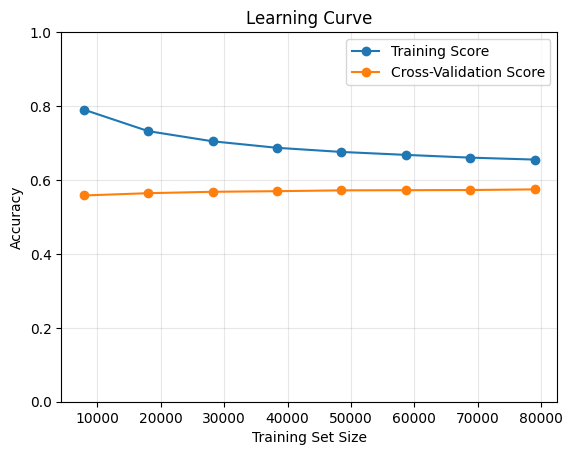

In [9]:
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o")
plt.plot(train_sizes, val_mean, marker="o")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(["Training Score", "Cross-Validation Score"])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))


Baseline accuracy: 0.5030492128776061


In [11]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)

Average precision: 0.6171521404224085


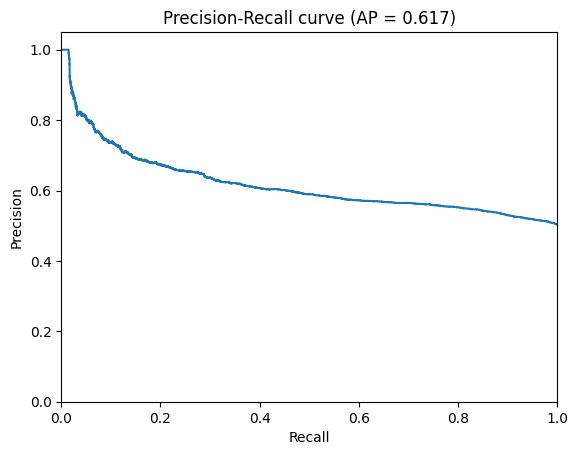

In [12]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

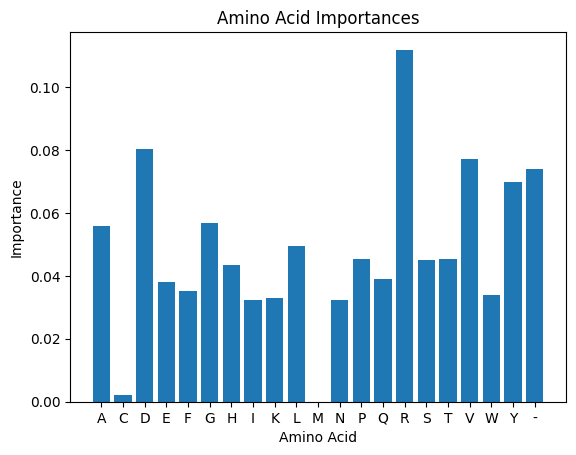

In [13]:
importances = clf.feature_importances_
plt.bar(list(amino_acids), importances)
plt.xlabel('Amino Acid')
plt.ylabel('Importance')
plt.title('Amino Acid Importances')
plt.show()

Test prediction

In [14]:
test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv")
x_test = pd.DataFrame([count_aminoacids(seq) for seq in test_df["CDR3 aligned"]])
y_test = test_df["Label"].values
clusters_test = test_df["Cluster_name"].values

In [15]:
y_scores_test = clf.predict_proba(x_test)[:, 1]
# labels at fixed threshold
y_pred_test = (y_scores_test >= 0.5).astype(int)

# standard metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

roc_auc = roc_auc_score(y_test, y_scores_test)
p, r, _ = precision_recall_curve(y_test, y_scores_test)
pr_auc = auc(r, p)

print("\n================ FULL TEST SET================\n")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print("\nConfusion matrix:")
print(cm)
print(f"\nROC-AUC (full test):   {roc_auc:.3f}")
print(f"PR-AUC (full test):    {pr_auc:.3f}")



================ FULL TEST SET================

Accuracy:  0.571
Precision: 0.572
Recall:    0.571
F1:        0.572

Confusion matrix:
[[7997 6019]
 [6038 8043]]

ROC-AUC (full test):   0.601
PR-AUC (full test):    0.596


In [16]:
print("\n================ Top-100 PREDICTIONS ONLY ================\n")
k =100
top_idx = np.argsort(-y_scores_test)[:k]
y_true_100 = y_test[top_idx]
tp_100 = np.sum(y_test[top_idx] == 1)
precision_100 = tp_100 / k
print(f"Precision@100: {precision_100:.3f}")
recall_100 = tp_100 / np.sum(y_test == 1)
print(f"Recall@100: {recall_100:.3f}")
n = len(y_test)
p = np.sum(y_test == 1)
ef_100 = (tp_100/k)/(p/n)
print(f"EF@100: {ef_100:.3f}")
assert len(clusters_test) == len(y_test)
diversity_100 = len(np.unique(clusters_test[top_idx]))
print(f"Diversity@100: {diversity_100}")
total_test_clusters = len(np.unique(clusters_test))
print("\nTotal clusters in test:", total_test_clusters)
normalized_diversity_100 = diversity_100 / total_test_clusters
print(f"Normalized diversity@100: {normalized_diversity_100:.3f}")
print("Top-K clusters:", np.unique(clusters_test[top_idx])[:10])

k1000 =1000
top1000_idx = np.argsort(-y_scores_test)[:k1000]
y_true_1000 = y_test[top1000_idx]
tp_1000 = np.sum(y_test[top1000_idx] == 1)
precision_1000 = tp_1000 / k1000
print(f"Precision@1000: {precision_1000:.3f}")

k2000 =2000
top2000_idx = np.argsort(-y_scores_test)[:k2000]
y_true_2000 = y_test[top2000_idx]
tp_2000 = np.sum(y_test[top2000_idx] == 1)
precision_2000 = tp_2000 / k2000
print(f"Precision@2000: {precision_2000:.3f}")

print("tp_1000:", tp_1000, "precision@1000:", tp_1000/1000)
print("tp_2000:", tp_2000, "precision@2000:", tp_2000/2000)



================ Top-100 PREDICTIONS ONLY ================

Precision@100: 0.910
Recall@100: 0.006
EF@100: 1.816
Diversity@100: 87

Total clusters in test: 26167
Normalized diversity@100: 0.003
Top-K clusters: [1491 2233 3181 3797 3862 4550 5119 5299 5301 5869]
Precision@1000: 0.710
Precision@2000: 0.677
tp_1000: 710 precision@1000: 0.71
tp_2000: 1355 precision@2000: 0.6775


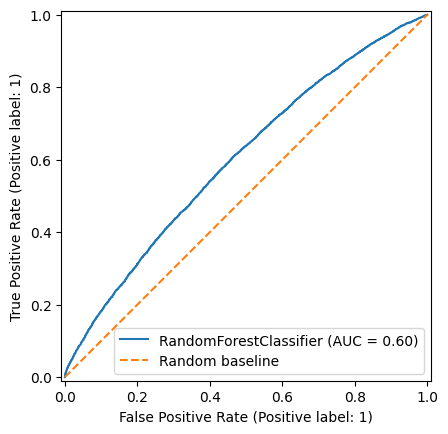

In [17]:
RocCurveDisplay.from_estimator(clf, x_test, y_test)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.legend()
plt.show()

In [18]:
top100_df =  test_df.iloc[top_idx].copy()
top100_df["y_true"] = y_test[top_idx]
top100_df["y_score"] = y_scores_test[top_idx]
top100_df["pred_label"] = y_pred_test[top_idx]


In [19]:
tp_top100_df = top100_df[
    (top100_df["y_true"] == 1) & (top100_df["pred_label"] == 1)
].copy()
tp_top100_df = tp_top100_df.rename(columns={"y_score": "pred_score"})


In [20]:
export_df = tp_top100_df[[
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]


In [21]:
export_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\Predictions\regularized_count_cdr3.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))


Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 91


c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


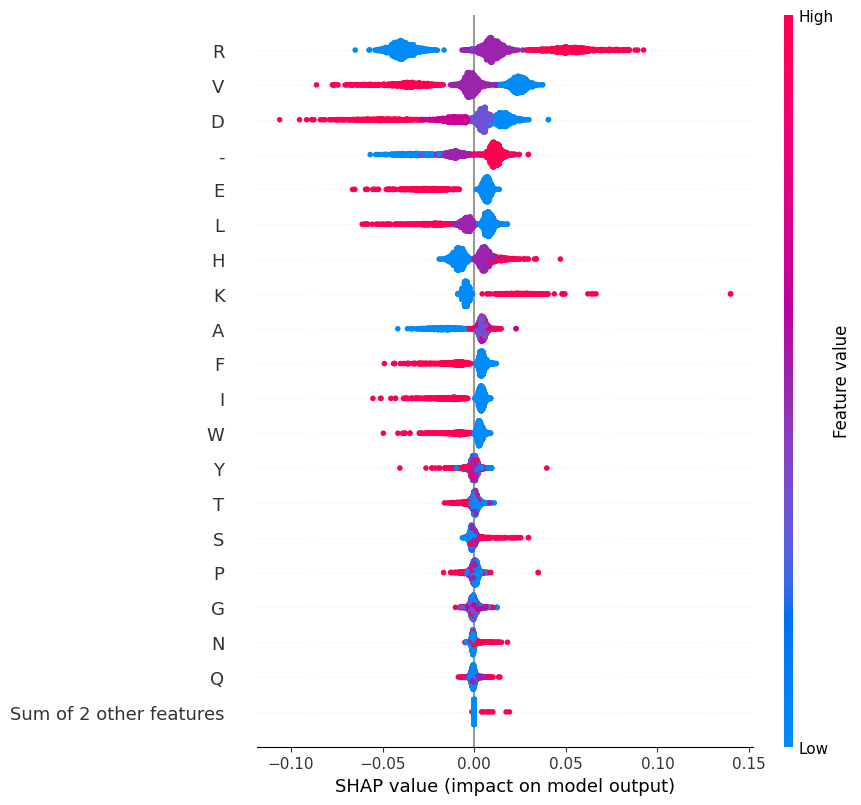

In [22]:
import shap

subset = x_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(clf)
sv = explainer(subset)          # sv is an Explanation

# If multi-class, select one class (e.g., 1)
if sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )

shap.plots.beeswarm(sv, max_display=20)


In [23]:
print(len(x_test))

28097


Number of label 1 sequences in top-100: 91


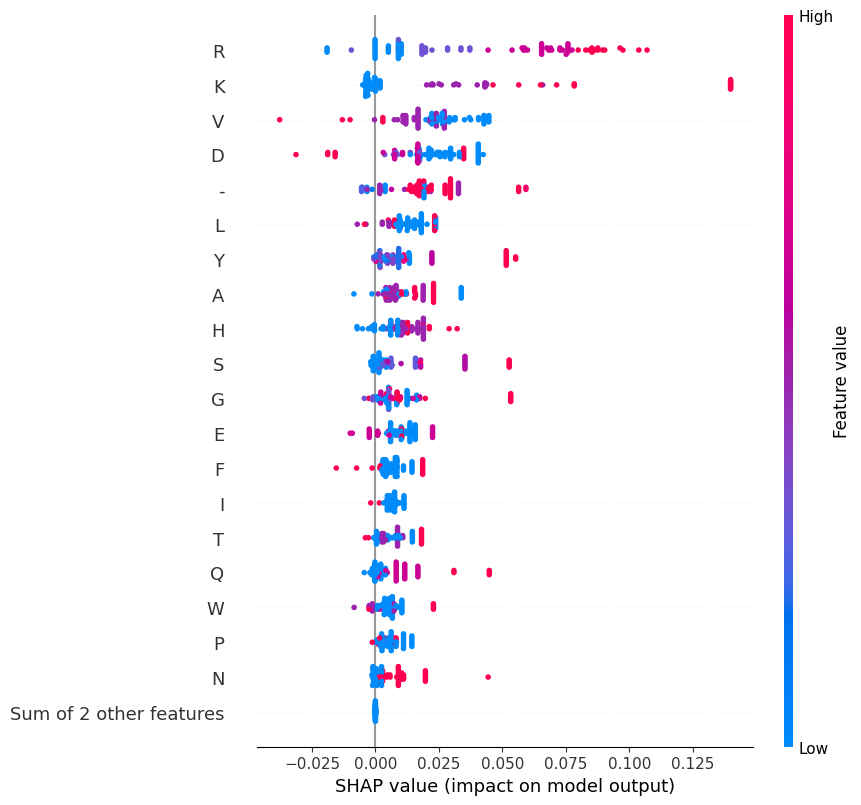

In [24]:
k =100
top_idx_shap = np.argsort(-y_scores_test)[:k]
top100_label1_idx = top_idx_shap[y_test[top_idx_shap] == 1]
print("Number of label 1 sequences in top-100:", len(top100_label1_idx))
subset_top100_pos = x_test.iloc[top100_label1_idx]
explainer_100 = shap.TreeExplainer(clf)
sv_100 = explainer_100(subset_top100_pos)

if sv_100.values.ndim == 3:
    class_idx = 1
    sv_100 = shap.Explanation(
        values=sv_100.values[:, :, class_idx],
        base_values=sv_100.base_values[:, class_idx],
        data=sv_100.data,
        feature_names=sv_100.feature_names
    )
shap.plots.beeswarm(sv_100, max_display=20)
